In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp

from scipy.stats import zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 
from matplotlib.colors import LinearSegmentedColormap

# Define paths
mcds_path = '/ceph/MethDev/pbio/hazel/gene_mcds/gene'
rna_path = '/ceph/MethDev/pbio/hazel/count_Arab13_with_TEs.csv'
meta_path = '/ceph/MethDev/pbio/hazel/merged_cluster_assignments.csv'
gene_list_path = 'hazel_list.txt'

In [2]:
# Load core datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

# Load Hazel's specific gene list
with open(gene_list_path, 'r') as file:
    my_gene_list = [line.strip() for line in file if line.strip()]

hazel_genes = pd.Index(my_gene_list)
print(f"Successfully loaded {len(hazel_genes)} genes from {gene_list_path}.")

Loaded RNA shape: (6071, 64507)
Loaded Meta shape: (5908, 1)
Successfully loaded 1238 genes from hazel_list.txt.


In [3]:
# Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# Normalize to CPM and Log1p
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6
rna_log1p = np.log1p(rna_cpm)

# Define Stage Merging Map
broad_cluster_mapping = {
    3: 'Mesophyll', 0: 'Mesophyll', 7: 'Mesophyll', 1: 'Mesophyll', 10: 'Mesophyll',
    5: 'Epidermis', 4: 'Epidermis', 6: 'Epidermis', 13: 'Epidermis', 8: 'Epidermis',
    14: 'Guard cell', 2: 'Vasculature', 11: 'PPP', 9: 'Phloem', 
    16: 'Myrosinase', 12: 'S phase', 15: 'G2M phase'
}

# Support both string and float keys to match metadata formatting safely
broad_cluster_mapping.update({str(k): v for k, v in broad_cluster_mapping.items()})
broad_cluster_mapping.update({float(k): v for k, v in broad_cluster_mapping.items() if isinstance(k, int)})

# Assign broad clusters and filter valid cells
meta['broad_cluster'] = meta['merged_cluster'].map(broad_cluster_mapping)
valid_cells = meta.loc[common_cells][meta.loc[common_cells, 'broad_cluster'].notna()].index

# Aggregate RNA by broad cluster
rna_log1p['cluster'] = meta.loc[valid_cells, 'broad_cluster']
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

print(f"Processed RNA matrix shape: {cluster_rna_matrix.shape}")

Processed RNA matrix shape: (64507, 9)


In [4]:
# Extract counts
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

# Align with valid metadata cells
valid_meth_cells = mCGN_mc.index.intersection(valid_cells)
mCGN_mc = mCGN_mc.loc[valid_meth_cells]
mCGN_cov = mCGN_cov.loc[valid_meth_cells]

# Assign broad cluster mappings
mCGN_mc['cluster'] = meta.loc[valid_meth_cells, 'broad_cluster']
mCGN_cov['cluster'] = meta.loc[valid_meth_cells, 'broad_cluster']

# Aggregate by broad cluster
cluster_c = mCGN_mc.groupby('cluster').sum().T
cluster_m = mCGN_cov.groupby('cluster').sum().T

# --- 1. Fit Global Offsets (deltas) ---
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# --- 2. Calculate Expected Methylation ---
gene_c = cluster_c.sum(axis=1)
gene_m = cluster_m.sum(axis=1)

# Mask for coverage
valid_genes_mask = gene_m >= 50 
cluster_c = cluster_c[valid_genes_mask]
cluster_m = cluster_m[valid_genes_mask]
gene_c = gene_c[valid_genes_mask]
gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# --- 3. Extract Residuals ---
obs_p = cluster_c / cluster_m.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

adj_meth_matrix = obs_p - p0_df

# Basic fraction filter: Must hit 10% methylation in at least one cluster
highly_meth_genes = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth_genes]

print(f"Logit-adjusted Methylation matrix shape: {filtered_meth_df.shape}")

Logit-adjusted Methylation matrix shape: (13610, 9)


In [5]:
filtered_meth_df

cluster,Epidermis,G2M phase,Guard cell,Mesophyll,Myrosinase,PPP,Phloem,S phase,Vasculature
gene,,,,,,,,,
AT1G03987,-0.000175,0.110977,-0.014732,-0.003930,-0.011746,-0.013390,0.019183,0.087555,-0.001610
AT1G01040,-0.015856,0.011052,0.060093,0.001921,0.020256,-0.014109,-0.029424,-0.013113,0.040854
AT1G01046,0.014642,0.157904,0.279442,-0.018887,-0.001032,0.068830,-0.140338,0.071834,0.075406
AT1G01050,-0.009256,0.077060,-0.014700,-0.000428,-0.009799,0.022093,0.045463,0.013978,0.006563
AT1G01060,0.002265,0.000287,0.038314,-0.004443,0.013724,0.030159,0.014071,0.006169,0.008565
...,...,...,...,...,...,...,...,...,...
ATMG01400,0.017582,-0.355809,-0.080245,0.063867,0.119294,-0.131360,-0.277515,-0.131422,-0.098287
ATMG01410,0.011203,-0.311277,-0.128146,0.051445,0.013147,0.005410,-0.249865,-0.104440,-0.125312
ATCG00890,-0.019480,-0.021711,-0.022799,0.003770,-0.018208,0.179263,-0.017244,-0.019285,-0.020931


In [6]:
# 1. Intersect across modalities AND restrict to Hazel's list
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index)#.intersection(hazel_genes)

final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]
final_weights_df = cluster_m.loc[common_genes]

# 2. Independent Filtering: Keep genes with >= 0.1 log1p CPM in at least one cluster
rna_expressed_mask = final_rna_df.max(axis=1) >= 0.1
robust_common_genes = final_rna_df[rna_expressed_mask].index

final_rna_df = final_rna_df.loc[robust_common_genes]
final_meth_df = final_meth_df.loc[robust_common_genes]
final_weights_df = final_weights_df.loc[robust_common_genes]

print(f"Genes remaining for WLS after all filters: {len(robust_common_genes)}")

# 3. Run Weighted Least Squares (WLS)
correlations = []
p_values = []
valid_genes = []

for gene in robust_common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    weight_vals = final_weights_df.loc[gene].values
    
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    rna_z = zscore(rna_vals)
    meth_z = zscore(meth_vals)
    X = sm.add_constant(meth_z)
    
    try:
        wls_model = sm.WLS(endog=rna_z, exog=X, weights=weight_vals).fit()
        valid_genes.append(gene)
        correlations.append(wls_model.params[1])
        p_values.append(wls_model.pvalues[1])
    except Exception:
        continue

# 4. Compile and Correct (FDR)
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

if len(stats_df) > 0:
    stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]
    significant_genes = stats_df[stats_df['fdr'] < 0.05]
    top_300_genes = significant_genes.sort_values('rho').head(300).index
    
    print(f"\nFound {len(significant_genes)} statistically significant genes (FDR < 0.05).")
    print(f"Top 10 candidates from Hazel's list:")
    display(stats_df.loc[top_300_genes].head(10))
else:
    print("WARNING: stats_df is empty!")

Genes remaining for WLS after all filters: 9344

Found 41 statistically significant genes (FDR < 0.05).
Top 10 candidates from Hazel's list:


,rho,p_value,fdr
gene,,,
AT1G58290,-1.876507,1.434894e-04,0.036237
AT2G34430,-1.702575,4.616419e-05,0.016591
AT3G60290,-1.658440,3.218510e-05,0.013076
AT3G26290,-1.610655,4.464666e-05,0.016591
AT5G35740,-1.560317,1.075830e-04,0.031332
AT1G51440,-1.528498,1.181413e-04,0.032468
AT5G41761,-1.468118,1.568580e-04,0.038571
AT1G66100,-1.420310,1.237136e-05,0.006800
AT5G52060,-1.395994,2.073623e-05,0.009688


In [7]:
common_genes

Index(['AT1G01040', 'AT1G01046', 'AT1G01050', 'AT1G01060', 'AT1G01150',
       'AT1G01220', 'AT1G01240', 'AT1G01260', 'AT1G01320', 'AT1G01340',
       ...
       'ATMG01260', 'ATMG01275', 'ATMG01280', 'ATMG01330', 'ATMG01350',
       'ATMG01360', 'ATMG01370', 'ATMG01380', 'ATMG01390', 'ATMG01410'],
      dtype='object', length=13599)

In [27]:
import numpy as np
from scipy.stats import zscore

# 1. Prepare Z-scored matrices 
# We Z-score RNA and the Methylation Residuals across the clusters
rna_z_df = final_rna_df.apply(zscore, axis=1)
meth_z_df = final_meth_df.apply(zscore, axis=1)

# 2. Calculate the "Inverse Intensity" (RNA_Z minus Meth_Z)
# Positive = RNA is high/Meth is low (Active state)
# Negative = RNA is low/Meth is high (Silenced state)
diff_df = rna_z_df - meth_z_df

# 3. For each gene, find which cluster has the absolute maximum difference
stats_df['key_cluster'] = diff_df.abs().idxmax(axis=1)

# --- THE FIX: Replace .lookup() with NumPy indexing ---
# We find the integer location for each 'key_cluster' column
row_idx = np.arange(len(diff_df))
col_idx = [diff_df.columns.get_loc(c) for c in stats_df['key_cluster']]

# Extract the specific values at those coordinates
stats_df['max_diff_val'] = diff_df.values[row_idx, col_idx]

# 4. Assign the state based on the sign of that difference
stats_df['key_state'] = np.where(stats_df['max_diff_val'] > 0, 'Active', 'Silenced')

print("Cluster assignment complete. You can now filter by key_cluster!")

Cluster assignment complete. You can now filter by key_cluster!


In [28]:
# Define the dominant clusters to ignore
dominant_clusters = ['Mesophyll', 'Epidermis']

# Filter for significant genes driven by minority tissues
minority_hits = stats_df[
    (stats_df['fdr'] < 0.05) & 
    (~stats_df['key_cluster'].isin(dominant_clusters))
].sort_values('rho')

print(f"Displaying all {len(minority_hits)} non-dominant cluster genes:")
display(minority_hits)

Displaying all 9 non-dominant cluster genes:


,rho,p_value,fdr,key_cluster,max_diff_val,key_state
gene,,,,,,
AT5G35740,-1.560317,1.075830e-04,0.031332,Myrosinase,-3.065436,Silenced
AT5G15980,-1.253764,1.358864e-04,0.035270,Guard cell,-3.347875,Silenced
AT1G70790,-0.993426,9.690487e-05,0.029209,S phase,3.111017,Active
AT1G51980,-0.957270,6.512802e-07,0.001938,Phloem,3.624530,Active
AT3G19290,-0.848166,1.520534e-06,0.001938,Myrosinase,4.790436,Active
AT5G38865,-0.836332,1.637133e-04,0.038716,S phase,3.432876,Active
AT1G62030,-0.813563,9.947929e-08,0.000930,Guard cell,4.325016,Active
AT1G04800,0.976173,3.082705e-06,0.002619,PPP,-0.226899,Silenced
AT5G07180,1.070597,1.773502e-04,0.040419,Myrosinase,-1.395313,Silenced


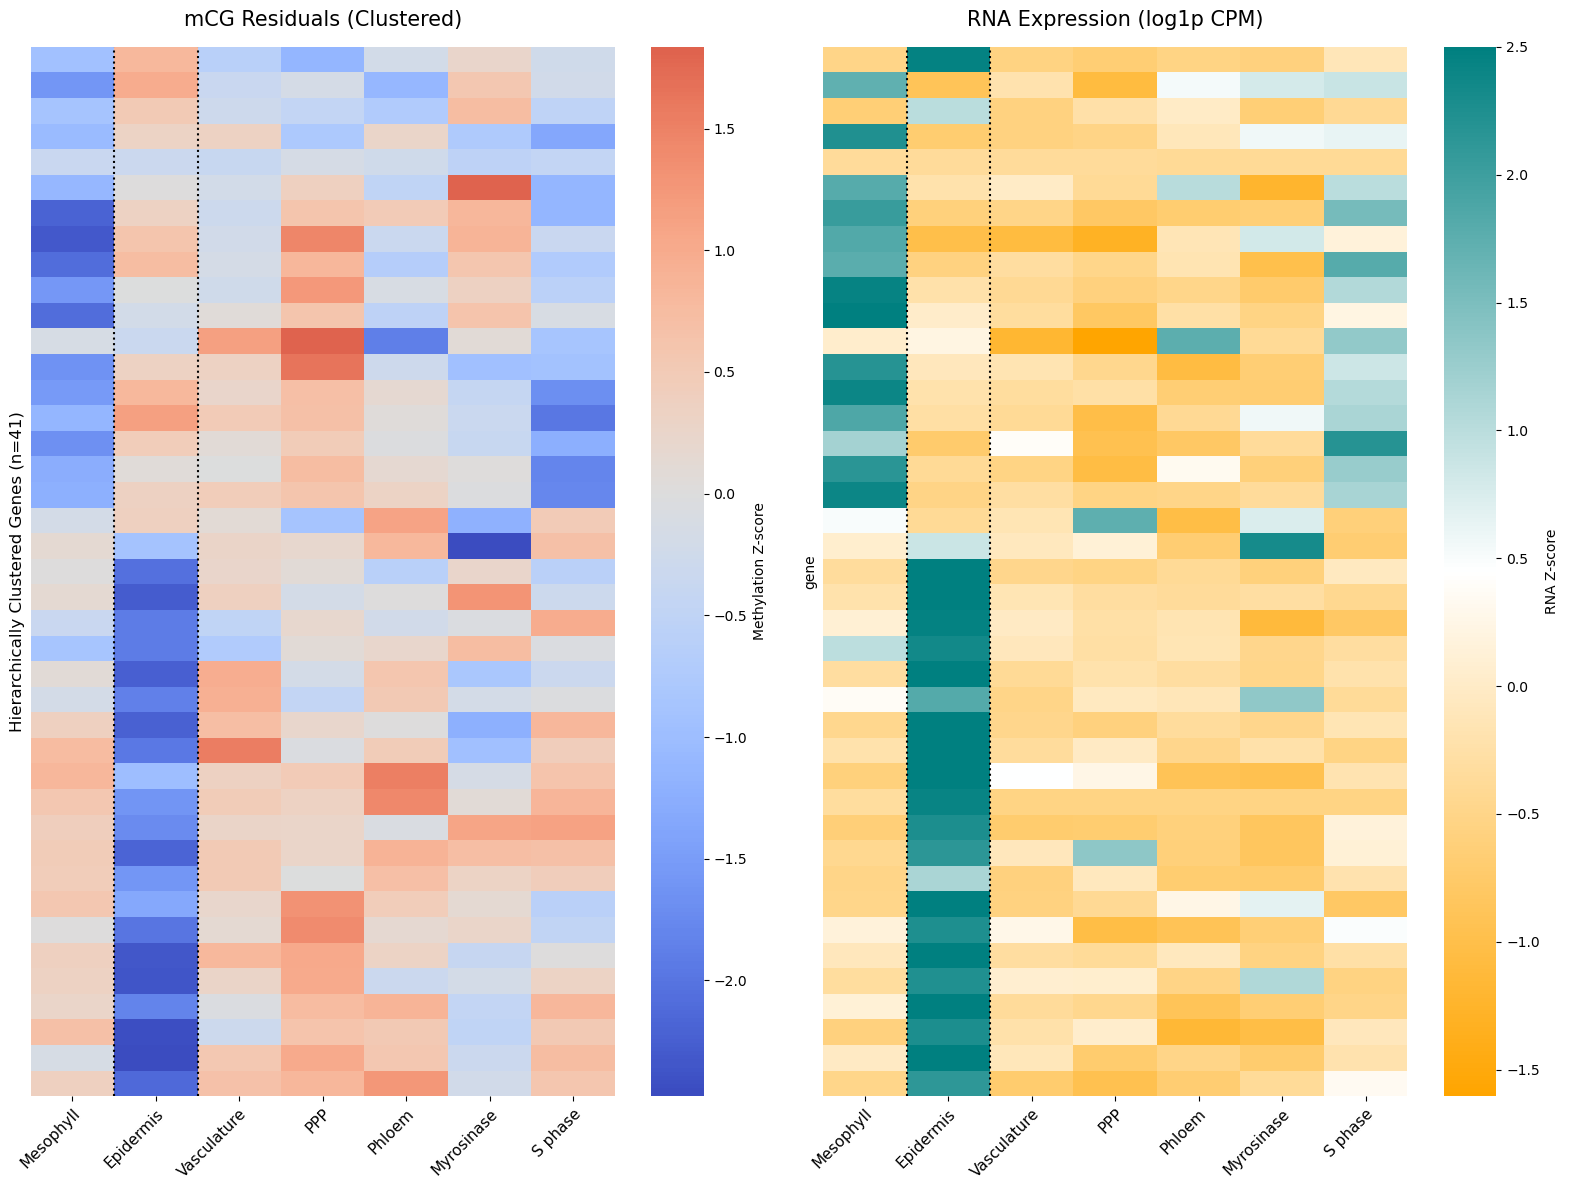

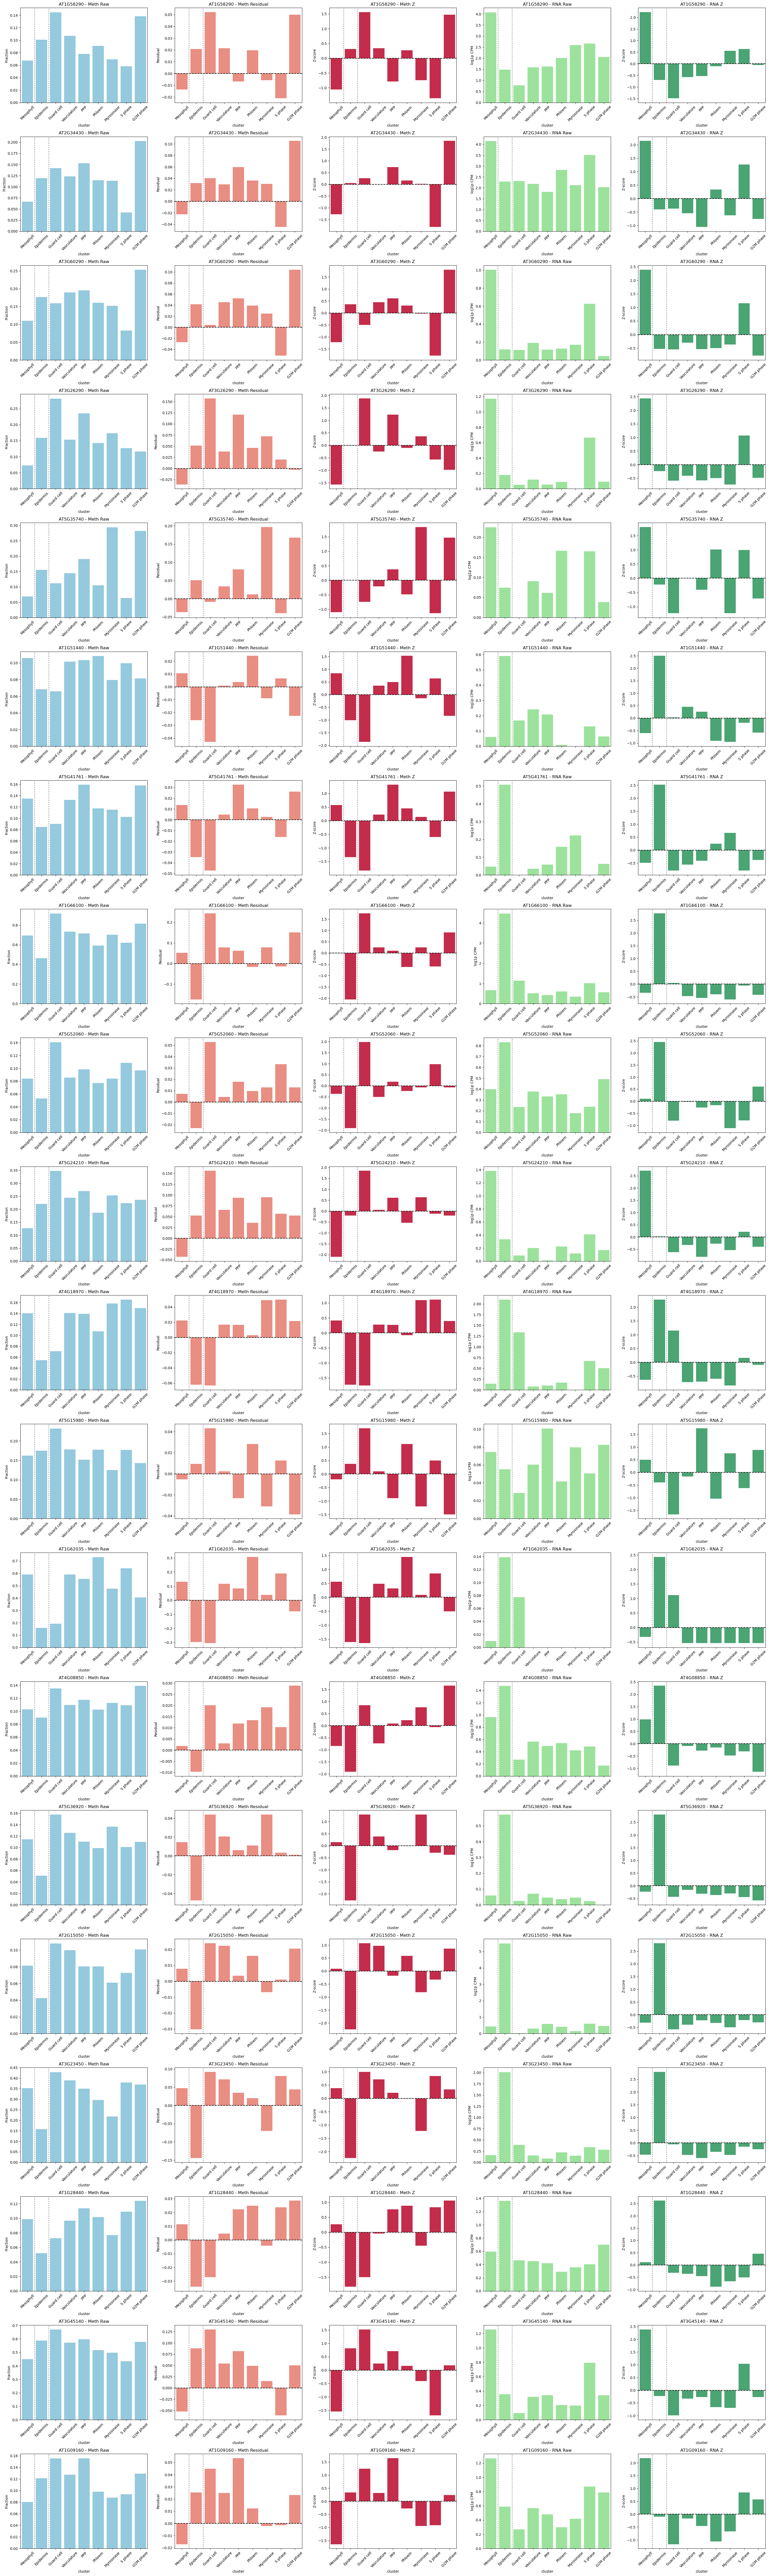

In [29]:
cluster_order = [
    'Mesophyll', 'Epidermis', 'Guard cell', 'Vasculature', 
    'PPP', 'Phloem', 'Myrosinase', 'S phase', 'G2M phase'
]

# --- A. HEATMAP PREPARATION ---
def prepare_zscore(df, genes):
    subset = df.loc[genes]
    z = subset.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5)

vis_meth_z = prepare_zscore(final_meth_df, top_300_genes)
vis_rna_z = prepare_zscore(final_rna_df, top_300_genes)

# Exclude specific clusters for the heatmap
clusters_to_drop = ["Guard cell", "G2M phase"] 
valid_order = [c for c in cluster_order if c in vis_meth_z.columns and c not in clusters_to_drop]

vis_meth_sorted = vis_meth_z[valid_order]
vis_rna_sorted = vis_rna_z[valid_order]

# Hierarchical Clustering (Rows)
row_linkage = hc.linkage(sp.distance.pdist(vis_meth_sorted.values), method='ward')
clustered_genes = vis_meth_sorted.index[hc.leaves_list(row_linkage)]

vis_meth_clustered = vis_meth_sorted.loc[clustered_genes]
vis_rna_clustered = vis_rna_sorted.loc[clustered_genes]

# Plot Heatmaps
rna_cmap = LinearSegmentedColormap.from_list("Orange_White_Teal", ["orange", "white", "teal"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12))

sns.heatmap(vis_meth_clustered, cmap="coolwarm", center=0, ax=ax1, cbar_kws={'label': 'Methylation Z-score'}, yticklabels=False)
ax1.set_title("mCG Residuals (Clustered)", fontsize=15, pad=15)
ax1.set_ylabel(f"Hierarchically Clustered Genes (n={len(top_300_genes)})", fontsize=12)

sns.heatmap(vis_rna_clustered, cmap=rna_cmap, ax=ax2, cbar_kws={'label': 'RNA Z-score'}, yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=15, pad=15)

for ax in [ax1, ax2]:
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    ax.tick_params(axis='x', labelsize=11)
    
    # Add dividers for Mesophyll and Epidermis
    for i, col_name in enumerate(valid_order):
        if col_name in ["Mesophyll", "Epidermis"]:
            ax.axvline(i + 1, color='black', lw=1.5, linestyle=':')

plt.tight_layout()
plt.show()

# --- B. DETAILED BAR PLOTS (TOP 20) ---
top_20_genes = top_300_genes[:20]
fig2, axes2 = plt.subplots(len(top_20_genes), 5, squeeze=False, figsize=(30, 5 * len(top_20_genes)))

for i, gene in enumerate(top_20_genes):
    meth_raw = obs_p.loc[gene].reindex(cluster_order)
    meth_adj = final_meth_df.loc[gene].reindex(cluster_order)
    meth_z = pd.Series(zscore(meth_adj.dropna()), index=meth_adj.dropna().index).reindex(cluster_order)
    
    rna_raw = final_rna_df.loc[gene].reindex(cluster_order)
    rna_z = pd.Series(zscore(rna_raw.dropna()), index=rna_raw.dropna().index).reindex(cluster_order)

    # Panels
    sns.barplot(x=meth_raw.index, y=meth_raw.values, ax=axes2[i, 0], color='skyblue').set(title=f"{gene} - Meth Raw", ylabel="Fraction")
    sns.barplot(x=meth_adj.index, y=meth_adj.values, ax=axes2[i, 1], color='salmon').set(title=f"{gene} - Meth Residual", ylabel="Residual")
    sns.barplot(x=meth_z.index, y=meth_z.values, ax=axes2[i, 2], color='crimson').set(title=f"{gene} - Meth Z", ylabel="Z-score")
    sns.barplot(x=rna_raw.index, y=rna_raw.values, ax=axes2[i, 3], color='lightgreen').set(title=f"{gene} - RNA Raw", ylabel="log1p CPM")
    sns.barplot(x=rna_z.index, y=rna_z.values, ax=axes2[i, 4], color='mediumseagreen').set(title=f"{gene} - RNA Z", ylabel="Z-score")
    
    for ax in axes2[i]:
        ax.tick_params(axis='x', rotation=45)
        ax.axvline(0.5, color='gray', linestyle=':', lw=2)
        ax.axvline(1.5, color='gray', linestyle=':', lw=2)
        if ax in [axes2[i, 1], axes2[i, 2], axes2[i, 4]]:
            ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.show()

In [30]:
def inspect_gene(gene):
    """
    Generates a statistical summary table and a 5-panel multi-omic bar chart 
    for a specific gene, aligning RNA expression and Methylation residuals.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 1. Configuration & Alignment
    cluster_order = ['Mesophyll', 'Epidermis', 'Guard cell', 'Vasculature', 'PPP', 'Phloem', 'Myrosinase', 'S phase', 'G2M phase']
    
    # Check existence
    has_rna = gene in cluster_rna_matrix.index
    has_meth = gene in cluster_m.index
    
    if not has_rna and not has_meth:
        print(f"❌ Error: Gene {gene} not found in RNA or Methylation matrices.")
        return

    # 2. Data Gathering: RNA
    if has_rna:
        rna_raw = cluster_rna_matrix.loc[gene].reindex(cluster_order)
        # Handle zero variance for Z-score
        if rna_raw.std() == 0:
            rna_z = pd.Series(0, index=rna_raw.index)
        else:
            rna_z = pd.Series(zscore(rna_raw.dropna()), index=rna_raw.dropna().index).reindex(cluster_order)
        
        # Raw counts for the truth table
        temp_rna = rna_aligned[[gene]].copy()
        temp_rna['cluster'] = meta.loc[temp_rna.index, 'broad_cluster']
        gene_raw_counts = temp_rna.groupby('cluster')[gene].sum().reindex(cluster_order)
        
        # Cluster totals (RNA coverage equivalent)
        temp_totals = pd.DataFrame({'t': rna_aligned.sum(axis=1), 'c': meta.loc[rna_aligned.index, 'broad_cluster']})
        cluster_total_reads = temp_totals.groupby('c')['t'].sum().reindex(cluster_order)

    # 3. Data Gathering: Methylation
    if has_meth:
        m_raw = obs_p.loc[gene].reindex(cluster_order)
        # Use final_meth_df if available (the significant ones), otherwise fallback to the raw residuals
        m_resid = final_meth_df.loc[gene] if gene in final_meth_df.index else adj_meth_matrix.loc[gene]
        m_resid = m_resid.reindex(cluster_order)
        
        if m_resid.std() == 0:
            m_z = pd.Series(0, index=m_resid.index)
        else:
            m_z = pd.Series(zscore(m_resid.dropna()), index=m_resid.dropna().index).reindex(cluster_order)

    # --- PART A: PRINT SUMMARY TABLE ---
    print("=" * 60)
    print(f" 🧬 MULTI-OMIC PROFILE: {gene}")
    print("=" * 60)

    if has_rna:
        print("\n[RNA Metrics]")
        rna_df = pd.DataFrame({
            'Gene_Raw_Counts': gene_raw_counts, 
            'Cluster_Total_Reads': cluster_total_reads, 
            'log1p_CPM': rna_raw, 
            'Z_Score': rna_z
        })
        display(rna_df)

    if has_meth:
        print("\n[Methylation Metrics]")
        meth_df = pd.DataFrame({
            'Total_Coverage (m)': cluster_m.loc[gene], 
            'Obs_Fraction (p)': m_raw, 
            'Residual': m_resid, 
            'Z_Score': m_z
        })
        display(meth_df)

    # --- PART B: PLOT VISUALS ---
    fig, axes = plt.subplots(1, 5, figsize=(28, 5))
    plt.subplots_adjust(wspace=0.35)

    # Panel 1: Raw Methylation
    sns.barplot(x=m_raw.index, y=m_raw.values, ax=axes[0], color='skyblue')
    axes[0].set_title("1. Raw mCG Fraction", fontweight='bold', fontsize=12)
    axes[0].set_ylabel("Fraction (0-1)")

    # Panel 2: Methylation Residual
    sns.barplot(x=m_resid.index, y=m_resid.values, ax=axes[1], color='salmon')
    axes[1].set_title("2. mCG Residual", fontweight='bold', fontsize=12)
    axes[1].axhline(0, color='black', lw=1.2)

    # Panel 3: Methylation Z-Score
    sns.barplot(x=m_z.index, y=m_z.values, ax=axes[2], color='crimson')
    axes[2].set_title("3. Methylation Z-Score", fontweight='bold', fontsize=12)
    axes[2].axhline(0, color='black', lw=1.2)

    # Panel 4: RNA Expression
    sns.barplot(x=rna_raw.index, y=rna_raw.values, ax=axes[3], color='lightgreen')
    axes[3].set_title("4. RNA (log1p CPM)", fontweight='bold', fontsize=12)

    # Panel 5: RNA Z-Score
    sns.barplot(x=rna_z.index, y=rna_z.values, ax=axes[4], color='mediumseagreen')
    axes[4].set_title("5. RNA Z-Score", fontweight='bold', fontsize=12)
    axes[4].axhline(0, color='black', lw=1.2)

    # Global formatting
    for ax in axes:
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        ax.set_xlabel("")
        # Dotted lines to separate Mesophyll/Epidermis from minority tissues
        ax.axvline(0.5, color='gray', linestyle=':', lw=2, alpha=0.6)
        ax.axvline(1.5, color='gray', linestyle=':', lw=2, alpha=0.6)

    plt.suptitle(f"Multi-Omic Regulatory Signature: {gene}", fontsize=18, y=1.08, fontweight='bold')
    plt.show()

 🧬 MULTI-OMIC PROFILE: AT3G55735

[RNA Metrics]


,Gene_Raw_Counts,Cluster_Total_Reads,log1p_CPM,Z_Score
Mesophyll,190,1204316585,0.008343,-0.300373
Epidermis,4841,511793390,0.292864,2.821260
Guard cell,0,18427738,0.000000,-0.391910
Vasculature,0,217839544,0.000000,-0.391910
PPP,0,47128676,0.000000,-0.391910
Phloem,13,87470004,0.020278,-0.169425
Myrosinase,0,14648681,0.000000,-0.391910
S phase,0,41966560,0.000000,-0.391910
G2M phase,0,19867685,0.000000,-0.391910



[Methylation Metrics]


,Total_Coverage (m),Obs_Fraction (p),Residual,Z_Score
cluster,,,,
Epidermis,488,0.268443,-0.153664,-1.603007
G2M phase,26,0.807692,0.358368,0.966248
Guard cell,3,1.000000,0.538275,1.868979
Mesophyll,1259,0.451152,0.025491,-0.704048
Myrosinase,19,0.736842,0.331417,0.831017
PPP,28,0.607143,0.169387,0.017989
Phloem,69,0.536232,0.144083,-0.108983
S phase,33,0.454545,0.034932,-0.656677
Vasculature,219,0.484018,0.043932,-0.611518


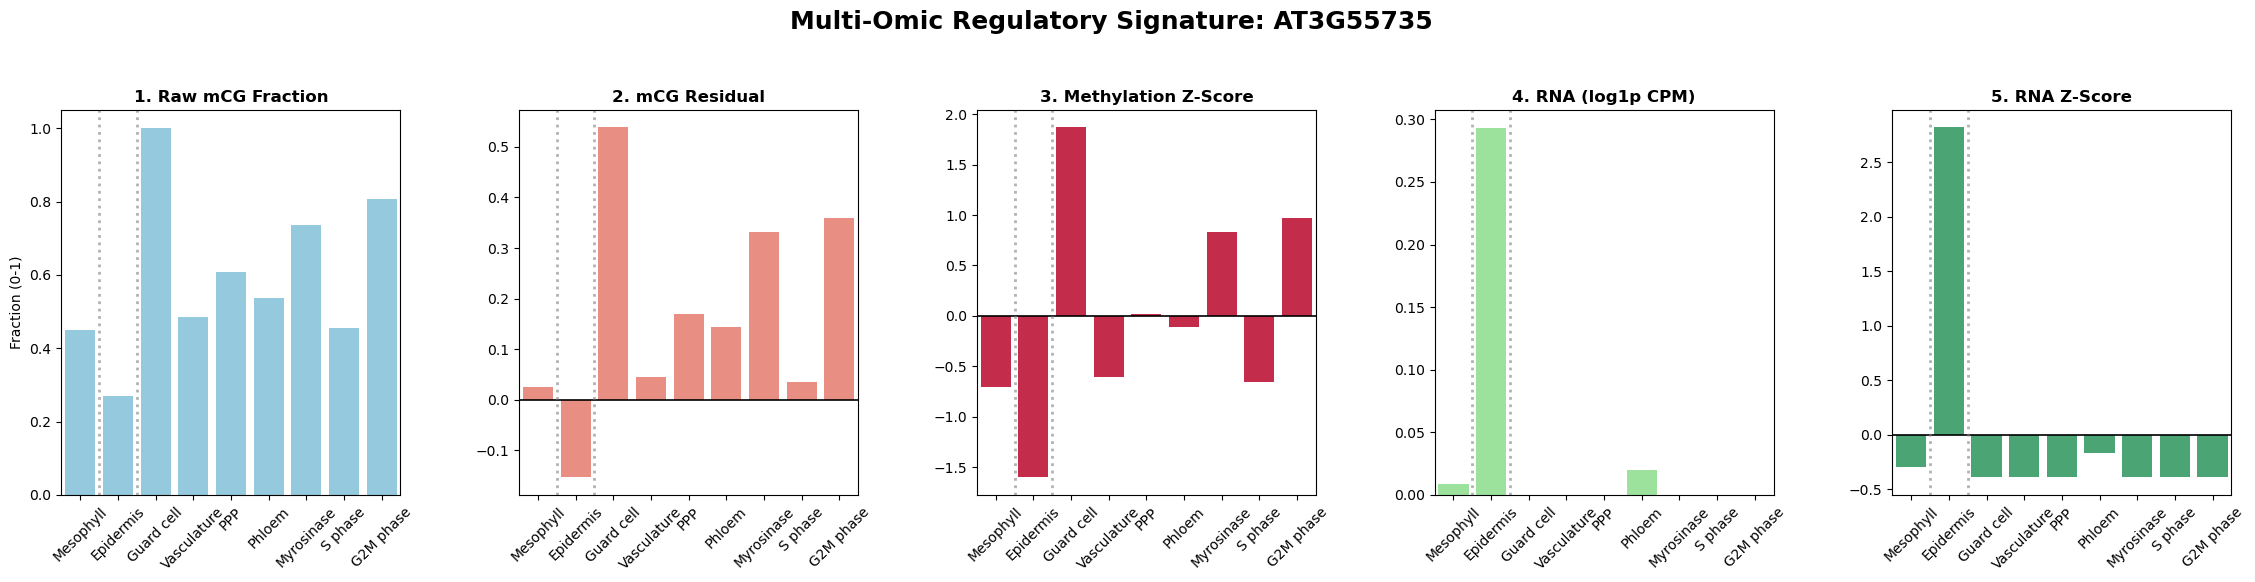

In [25]:
inspect_gene("AT3G55735")

 🧬 MULTI-OMIC PROFILE: AT1G58290

[RNA Metrics]


,Gene_Raw_Counts,Cluster_Total_Reads,log1p_CPM,Z_Score
Mesophyll,823742,1204316585,4.073311,2.229348
Epidermis,78170,511793390,1.481049,-0.694936
Guard cell,1024,18427738,0.779020,-1.486881
Vasculature,44149,217839544,1.590544,-0.571416
PPP,10556,47128676,1.631626,-0.525072
Phloem,21730,87470004,2.006036,-0.102707
Myrosinase,2140,14648681,2.597206,0.564181
S phase,22206,41966560,2.659793,0.634785
G2M phase,6750,19867685,2.055150,-0.047302



[Methylation Metrics]


,Total_Coverage (m),Obs_Fraction (p),Residual,Z_Score
cluster,,,,
Epidermis,17007,0.100723,0.020846,0.313030
G2M phase,528,0.138258,0.049854,1.469278
Guard cell,318,0.144654,0.052138,1.560284
Mesophyll,37034,0.067371,-0.013582,-1.059286
Myrosinase,592,0.069257,-0.005709,-0.745449
PPP,987,0.078014,-0.006683,-0.784296
Phloem,1365,0.090842,0.019628,0.264456
S phase,791,0.058154,-0.020974,-1.353914
Vasculature,4829,0.106854,0.021420,0.335896


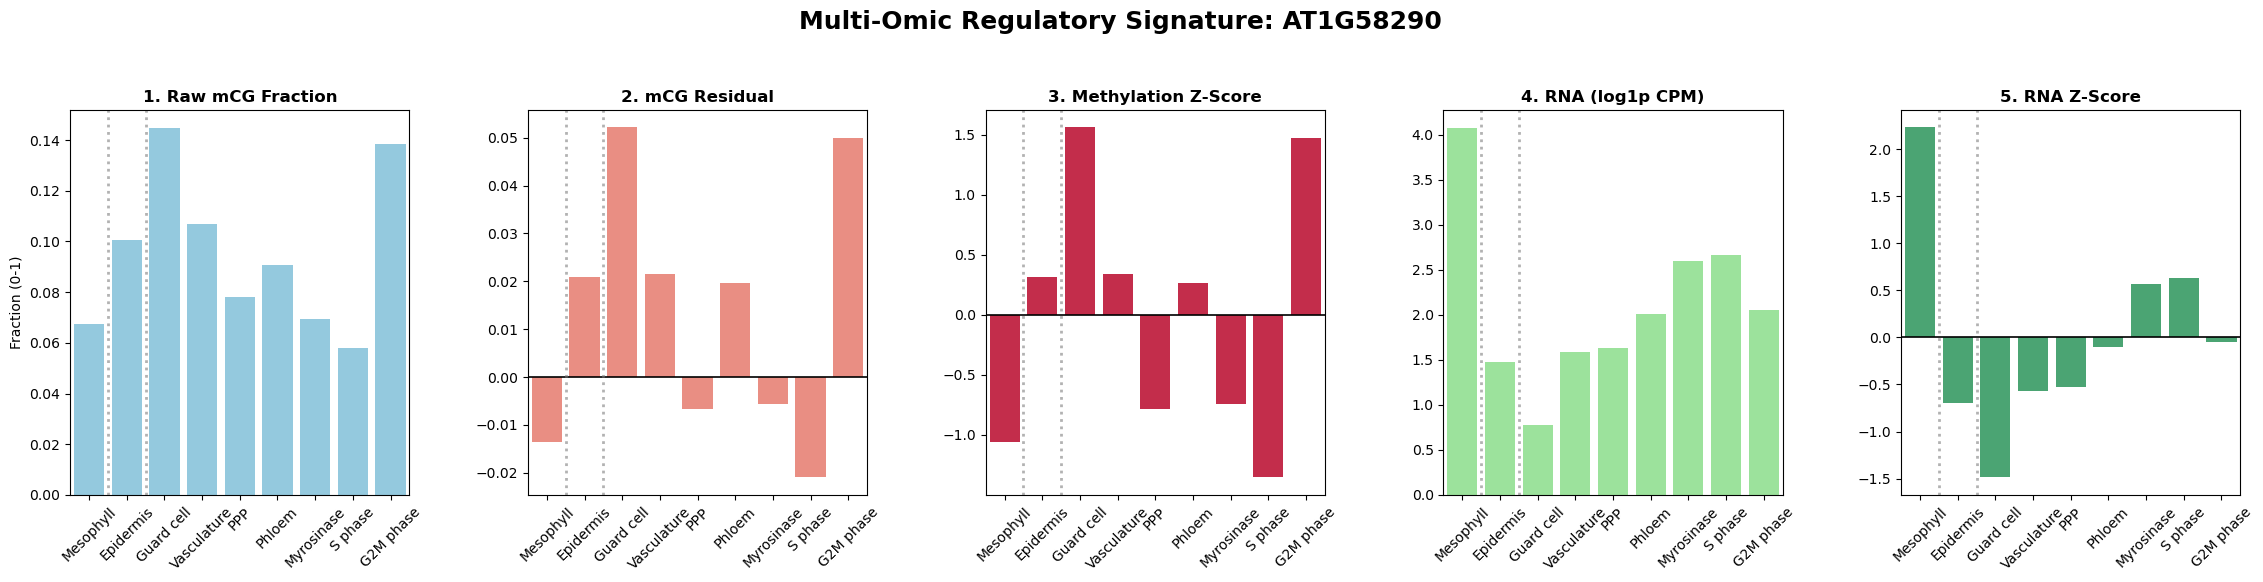

In [33]:
inspect_gene("AT1G58290")